<a href="https://colab.research.google.com/github/far162162/telco-churn-prediction./blob/main/Telco_Customer_Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [108]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.svm import LinearSVC
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score


# Predicting Customer Churn: A Strategic Machine Learning Approach

## Executive Summary & Business Objective
In the telecommunications industry, the Customer Acquisition Cost (CAC) is notoriously high. Research consistently shows that acquiring a new customer costs up to five times more than retaining an existing one. Therefore, minimizing customer attrition (churn) is a critical driver of profitability.

**Objective:** The goal of this analysis is to transition from reactive customer service to proactive customer retention. By developing a robust machine learning classification model, we aim to accurately predict which current customers are at the highest risk of leaving.

**Business Value:** A high-performing predictive model will allow the marketing and retention teams to efficiently allocate promotional budgets (e.g., discounts, targeted outreach) only to high-risk customers, maximizing ROI and protecting top-line revenue.

In [75]:
df=pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [77]:
df.shape

(7043, 21)

In [78]:
print(df.head(10))

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   
5  9305-CDSKC  Female              0      No         No       8          Yes   
6  1452-KIOVK    Male              0      No        Yes      22          Yes   
7  6713-OKOMC  Female              0      No         No      10           No   
8  7892-POOKP  Female              0     Yes         No      28          Yes   
9  6388-TABGU    Male              0      No        Yes      62          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL        

In [79]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [80]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


### 1. Data Quality & Preprocessing
**What the Code is Doing:** Before building predictive models, the raw data must be cleaned and transformed into a machine-readable format. We check for missing values, duplicates, and correct data types. Specifically, we identify that `TotalCharges` was improperly loaded as text due to blank spaces, which we coerce into numeric values. We also drop `customerID` as it provides no predictive power. Finally, we convert categorical variables (like "Yes"/"No") into binary 0s and 1s (One-Hot Encoding).

**Business Rationale:** Garbage in, garbage out. If financial metrics like `TotalCharges` are left as text strings, the model cannot mathematically assess the impact of pricing on customer loyalty. Proper data formatting ensures our algorithms extract valid, actionable business signals.

Data preprocessing

In [81]:
df.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [82]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
7038,False
7039,False
7040,False
7041,False


In [83]:
# TotalCharges is currently an object because of blank spaces. Convert to numeric.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].replace(' ', np.nan))

# Check for missing values
print(f"Missing values in TotalCharges: {df['TotalCharges'].isnull().sum()}")

# Since only 11 rows are missing (out of 7043), it's safe to drop them.
df.dropna(inplace=True)

# 3. Drop useless columns
# customerID adds no predictive value
df.drop('customerID', axis=1, inplace=True)

Missing values in TotalCharges: 11


In [84]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [85]:

categorical_cols = df.select_dtypes(include=['object']).columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [86]:
print("Data Preprocessing Complete. New shape:", df_encoded.shape)

Data Preprocessing Complete. New shape: (7032, 31)


**EDA**

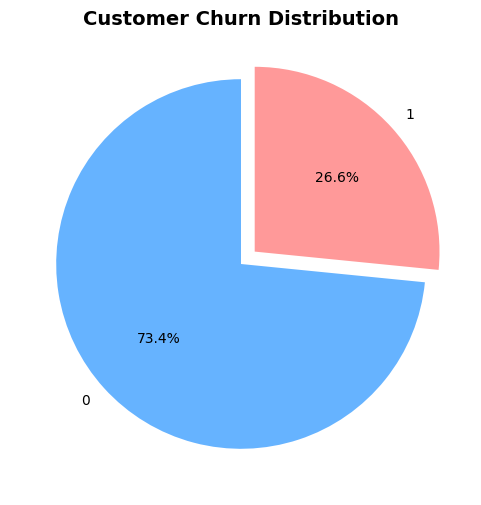

In [87]:
# Target Variable Distribution
plt.figure(figsize=(6, 6))
churn_counts = df['Churn'].value_counts()
plt.pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%',
        colors=['#66b3ff','#ff9999'], startangle=90, explode=(0, 0.1))
plt.title('Customer Churn Distribution', fontsize=14, fontweight='bold')
plt.show()


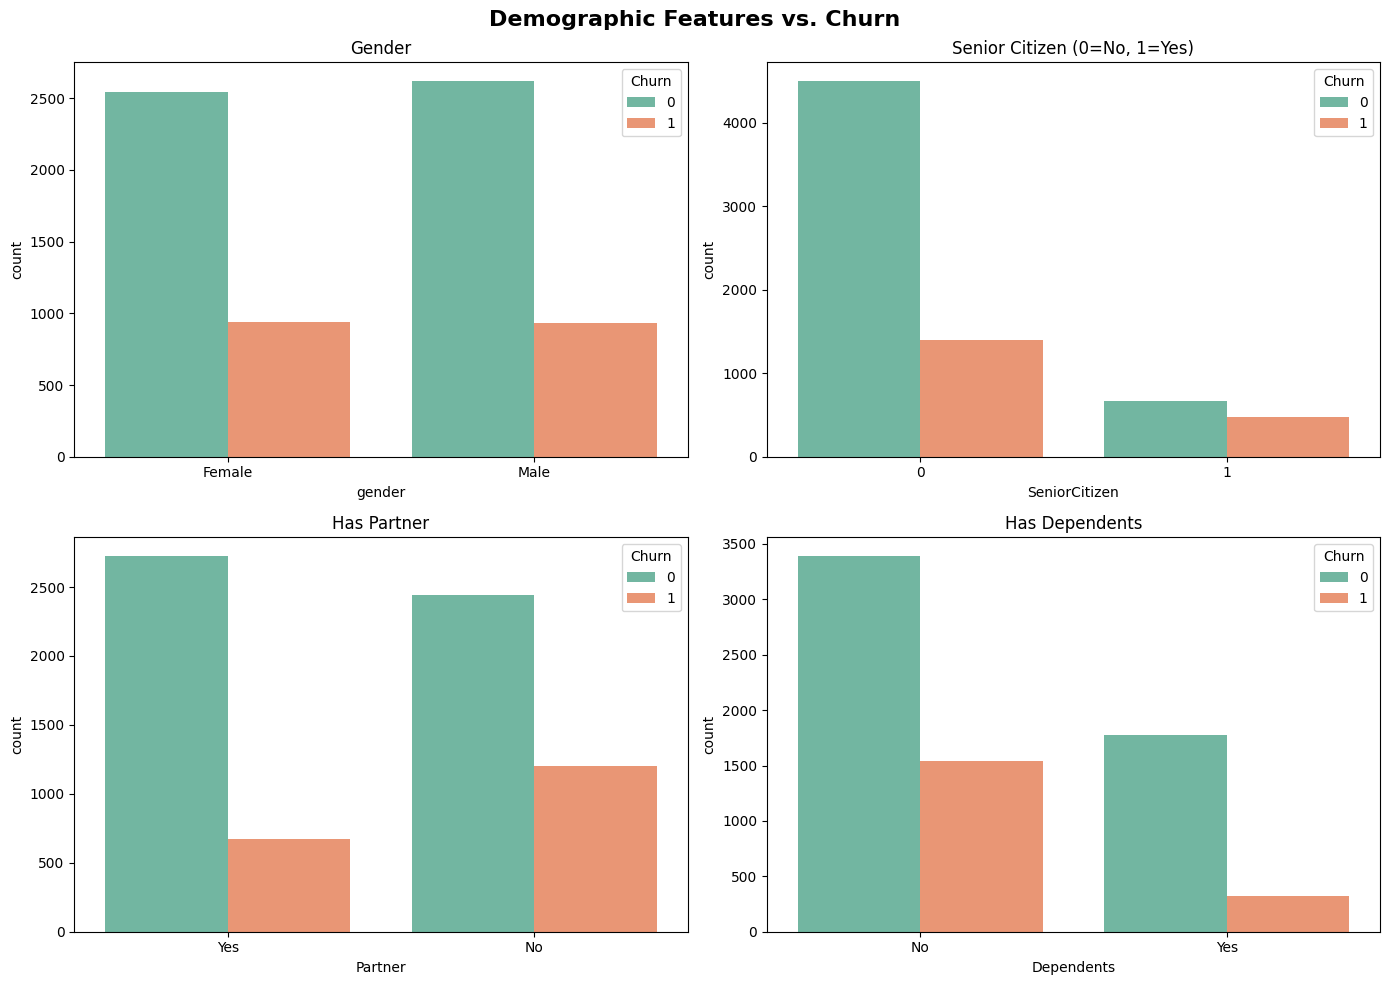

In [88]:
# Set up a 2x2 grid for Demographic plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Demographic Features vs. Churn', fontsize=16, fontweight='bold')

sns.countplot(data=df, x='gender', hue='Churn', palette='Set2', ax=axes[0, 0])
axes[0, 0].set_title('Gender')

sns.countplot(data=df, x='SeniorCitizen', hue='Churn', palette='Set2', ax=axes[0, 1])
axes[0, 1].set_title('Senior Citizen (0=No, 1=Yes)')

sns.countplot(data=df, x='Partner', hue='Churn', palette='Set2', ax=axes[1, 0])
axes[1, 0].set_title('Has Partner')

sns.countplot(data=df, x='Dependents', hue='Churn', palette='Set2', ax=axes[1, 1])
axes[1, 1].set_title('Has Dependents')

plt.tight_layout()
plt.show()

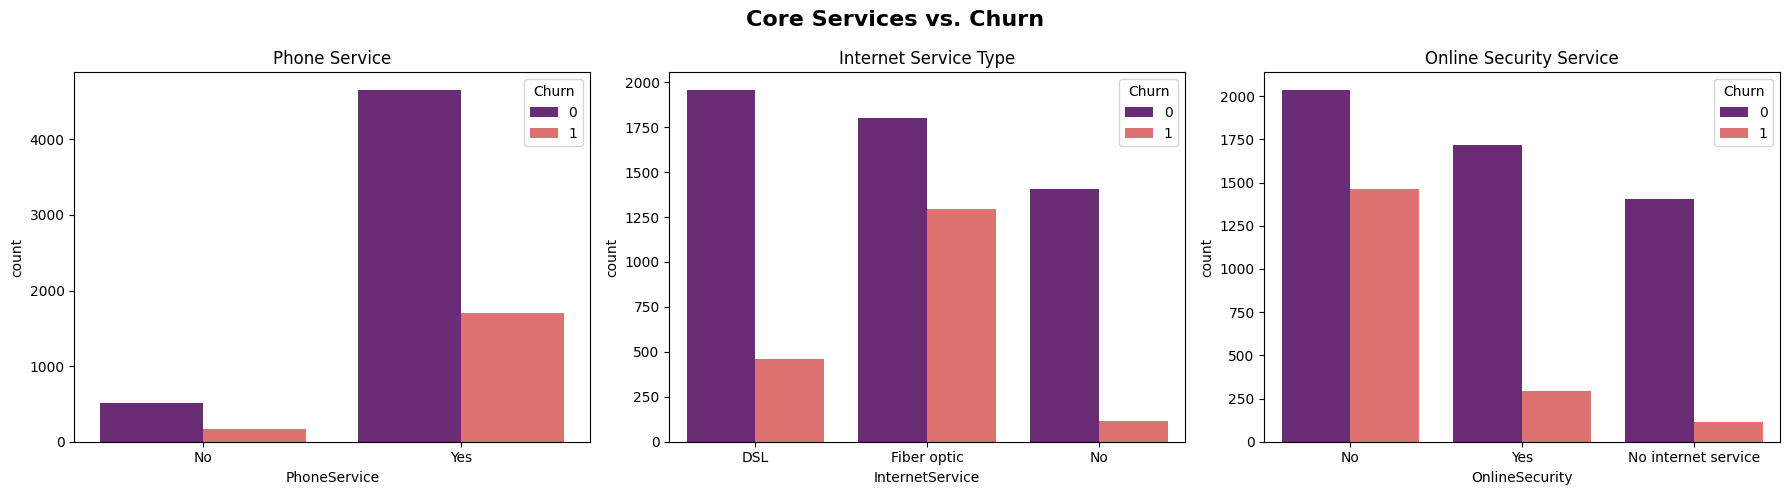

In [89]:
# Visualizing core services
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Core Services vs. Churn', fontsize=16, fontweight='bold')

sns.countplot(data=df, x='PhoneService', hue='Churn', palette='magma', ax=axes[0])
axes[0].set_title('Phone Service')

sns.countplot(data=df, x='InternetService', hue='Churn', palette='magma', ax=axes[1])
axes[1].set_title('Internet Service Type')

sns.countplot(data=df, x='OnlineSecurity', hue='Churn', palette='magma', ax=axes[2])
axes[2].set_title('Online Security Service')

plt.tight_layout()
plt.show()

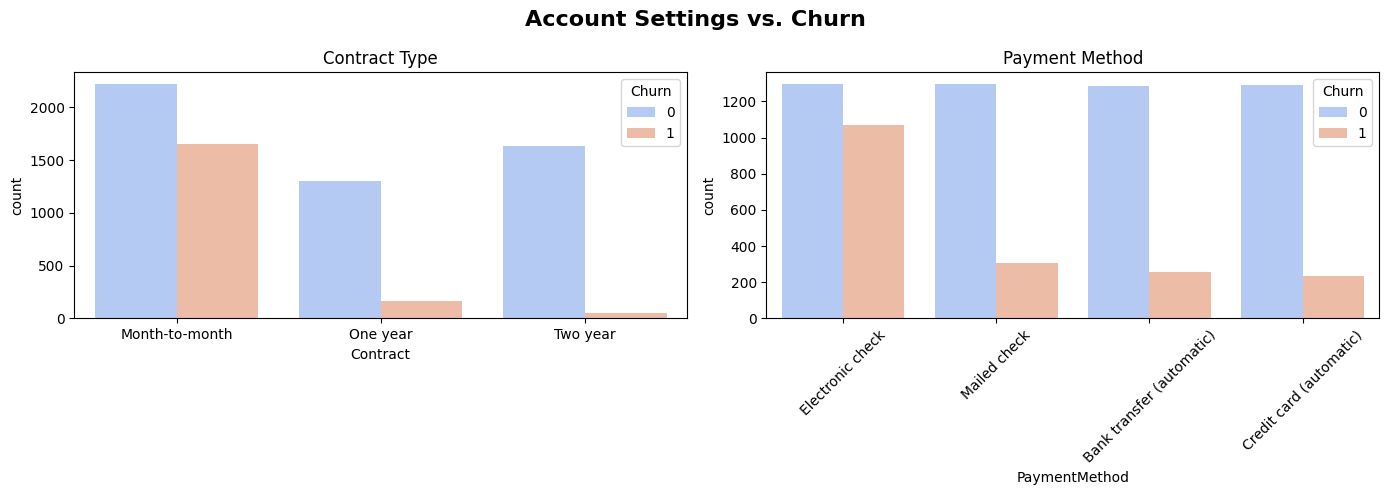

In [90]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Account Settings vs. Churn', fontsize=16, fontweight='bold')

sns.countplot(data=df, x='Contract', hue='Churn', palette='coolwarm', ax=axes[0])
axes[0].set_title('Contract Type')

sns.countplot(data=df, x='PaymentMethod', hue='Churn', palette='coolwarm', ax=axes[1])
axes[1].set_title('Payment Method')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


/tmp/ipykernel_4565/2546353389.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='TotalCharges', palette='muted', ax=axes[2])


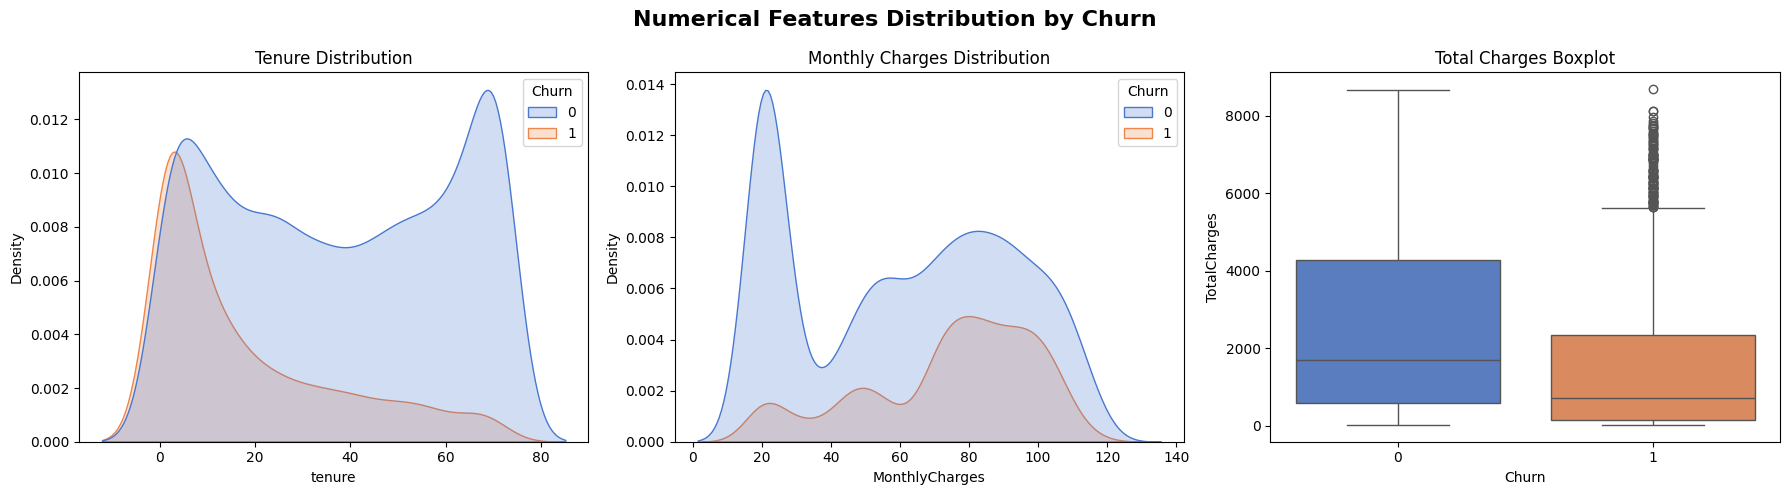

In [91]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Numerical Features Distribution by Churn', fontsize=16, fontweight='bold')

sns.kdeplot(data=df, x='tenure', hue='Churn', fill=True, palette='muted', ax=axes[0])
axes[0].set_title('Tenure Distribution')

sns.kdeplot(data=df, x='MonthlyCharges', hue='Churn', fill=True, palette='muted', ax=axes[1])
axes[1].set_title('Monthly Charges Distribution')

sns.boxplot(data=df, x='Churn', y='TotalCharges', palette='muted', ax=axes[2])
axes[2].set_title('Total Charges Boxplot')

plt.tight_layout()
plt.show()

### 2. Exploratory Data Analysis (EDA): Uncovering Behavioral Frictions
**What the Code is Doing:** We visualize the distribution of churn across different customer demographics, core telecom services, and account settings using count plots and KDE (Kernel Density Estimation) plots.

**Business Insights:**
* **The Contract Trap:** Customers on Month-to-Month contracts account for the vast majority of churn. Once a customer commits to a 1-year or 2-year contract, churn drops precipitously.
* **The Fiber Optic Paradox:** Counter-intuitively, customers paying for premium Fiber Optic internet churn at a significantly higher rate than DSL users. This points to a severe mismatch between price and perceived value, or potential network reliability issues.
* **Payment Friction:** Customers manually paying via "Electronic Check" are highly likely to churn compared to those on automatic credit card billing. Manual payments force the customer to re-evaluate their subscription every single month.

Correlation with Churn:
Churn                                    1.000000
InternetService_Fiber optic              0.307463
PaymentMethod_Electronic check           0.301455
MonthlyCharges                           0.192858
PaperlessBilling_Yes                     0.191454
SeniorCitizen                            0.150541
StreamingTV_Yes                          0.063254
StreamingMovies_Yes                      0.060860
MultipleLines_Yes                        0.040033
PhoneService_Yes                         0.011691
gender_Male                             -0.008545
MultipleLines_No phone service          -0.011691
DeviceProtection_Yes                    -0.066193
OnlineBackup_Yes                        -0.082307
PaymentMethod_Mailed check              -0.090773
PaymentMethod_Credit card (automatic)   -0.134687
Partner_Yes                             -0.149982
Dependents_Yes                          -0.163128
TechSupport_Yes                         -0.164716
OnlineSecurity_Yes        

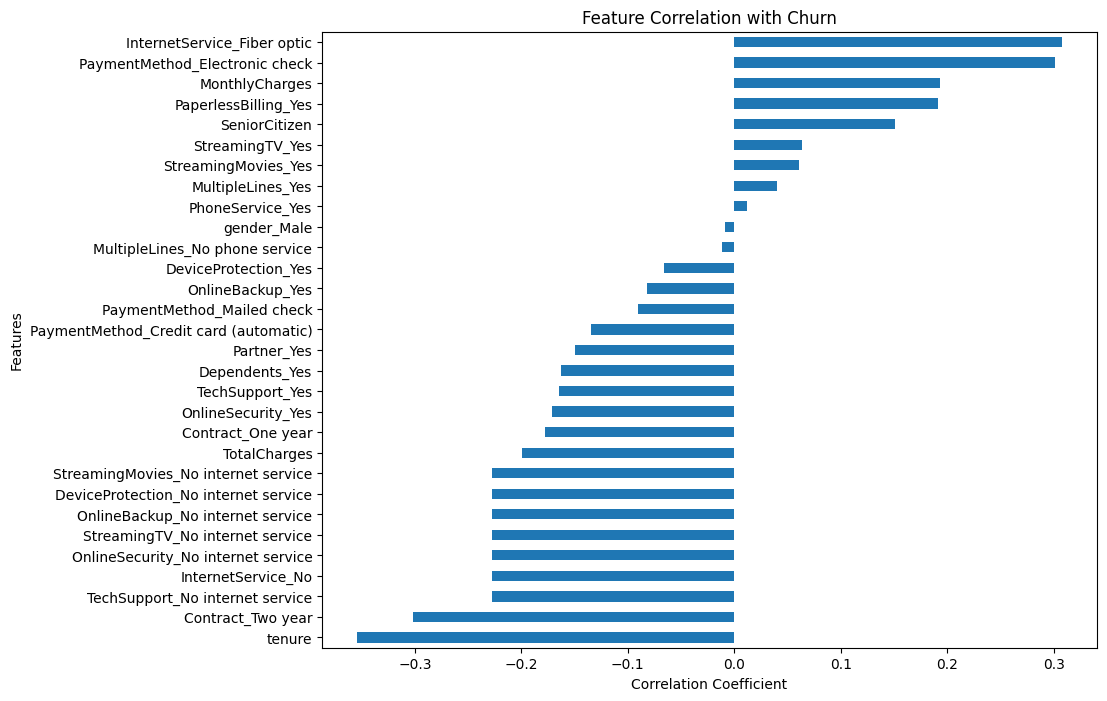

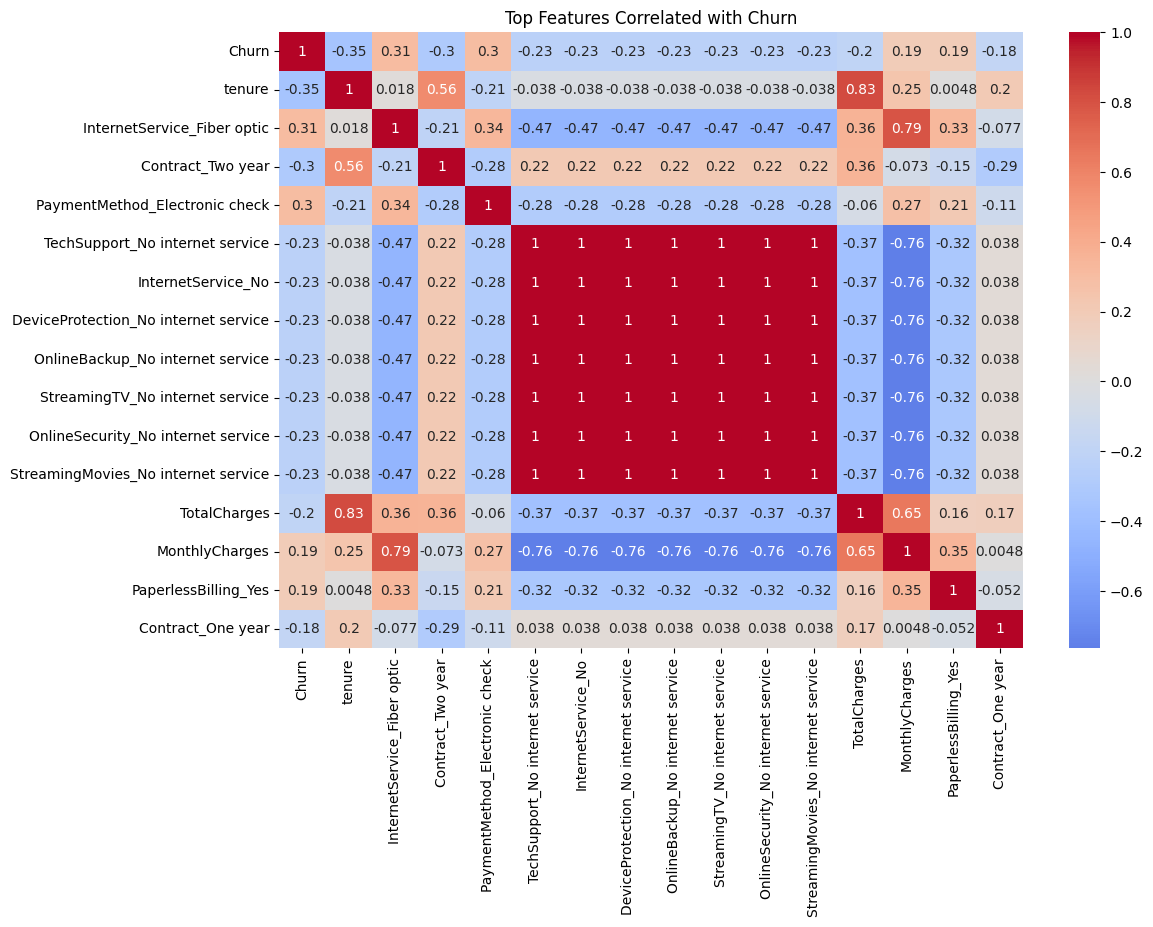

In [92]:
# 5. Correlation Analysis

corr_matrix = df_encoded.corr()

churn_corr = corr_matrix['Churn'].sort_values(ascending=False)

print("Correlation with Churn:")
print(churn_corr)

# Plot correlation with Churn
plt.figure(figsize=(10, 8))
churn_corr.drop('Churn').sort_values().plot(kind='barh')
plt.title("Feature Correlation with Churn")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Features")
plt.show()

# Heatmap for top correlated features
top_corr_features = churn_corr.abs().sort_values(ascending=False).head(16).index

plt.figure(figsize=(12, 8))
sns.heatmap(
    df_encoded[top_corr_features].corr(),
    annot=True,
    cmap='coolwarm',
    center=0
)
plt.title("Top Features Correlated with Churn")
plt.show()

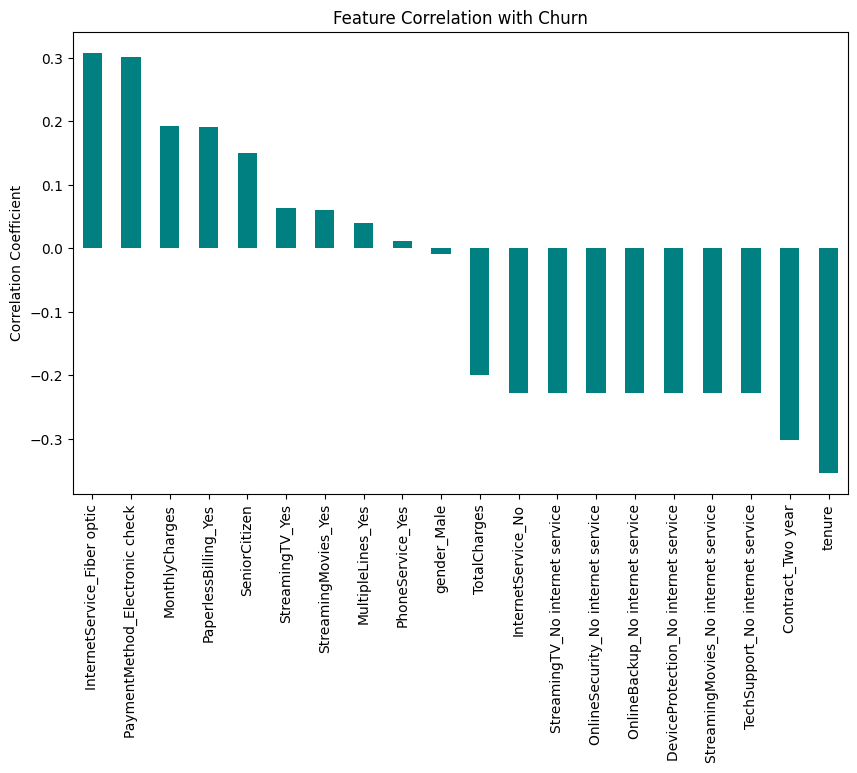

In [93]:
plt.figure(figsize=(10, 6))
# Calculate correlations with Churn
correlations = df_encoded.corr()['Churn'].sort_values(ascending=False)

# Plot top positive and negative correlations (excluding Churn itself)
correlations = correlations.drop('Churn')

# Use pd.concat instead of the deprecated .append()
combined_correlations = pd.concat([correlations.head(10), correlations.tail(10)])
combined_correlations.plot(kind='bar', color='teal')

plt.title('Feature Correlation with Churn')
plt.ylabel('Correlation Coefficient')
plt.show()

### 2. Exploratory Data Analysis (EDA): Uncovering Behavioral Frictions
**What the Code is Doing:** We visualize the distribution of churn across different customer demographics, core telecom services, and account settings using count plots and KDE (Kernel Density Estimation) plots.

**Business Insights:**
* **The Contract Trap:** Customers on Month-to-Month contracts account for the vast majority of churn. Once a customer commits to a 1-year or 2-year contract, churn drops precipitously.
* **The Fiber Optic Paradox:** Counter-intuitively, customers paying for premium Fiber Optic internet churn at a significantly higher rate than DSL users. This points to a severe mismatch between price and perceived value, or potential network reliability issues.
* **Payment Friction:** Customers manually paying via "Electronic Check" are highly likely to churn compared to those on automatic credit card billing. Manual payments force the customer to re-evaluate their subscription every single month.

**z score standardization**

In [94]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})


binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    if col == 'gender':
        df[col] = df[col].map({'Female': 1, 'Male': 0})
    else:
        df[col] = df[col].map({'Yes': 1, 'No': 0})


categorical_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity',
                    'OnlineBackup', 'DeviceProtection', 'TechSupport',
                    'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

scaler = StandardScaler()

df_encoded[numerical_cols] = scaler.fit_transform(df_encoded[numerical_cols])


print("Shape of fully processed and scaled data:", df_encoded.shape)
print("\nFirst 3 rows of the scaled data:\n")
print(df_encoded.head(3))

Shape of fully processed and scaled data: (7032, 31)

First 3 rows of the scaled data:

   gender  SeniorCitizen  Partner  Dependents    tenure  PhoneService  \
0       1              0        1           0 -1.280248             0   
1       0              0        0           0  0.064303             1   
2       0              0        0           0 -1.239504             1   

   PaperlessBilling  MonthlyCharges  TotalCharges  Churn  ...  \
0                 1       -1.161694     -0.994194    NaN  ...   
1                 0       -0.260878     -0.173740    NaN  ...   
2                 1       -0.363923     -0.959649    NaN  ...   

   TechSupport_Yes  StreamingTV_No internet service  StreamingTV_Yes  \
0            False                            False            False   
1            False                            False            False   
2            False                            False            False   

   StreamingMovies_No internet service  StreamingMovies_Yes  \
0     

Recursuive Feature Elimination
### 4. Feature Engineering: Isolating the Signal from the Noise
**What the Code is Doing:** We utilize Recursive Feature Elimination with Cross-Validation (RFECV). Instead of feeding all 30+ columns into our models, this algorithm iteratively trains the model, ranks the features by importance, and drops the weakest ones. We create a custom, optimized dataset for XGBoost, Linear SVM, and Random Forest.

**Business Rationale:** In business analytics, simpler is often better. By eliminating "noisy" variables (like gender or having a phone line, which have near-zero correlation with churn), we build models that are faster, less prone to overfitting, and easier to explain to non-technical stakeholders.

In [101]:
# The 'Churn' column in df_encoded (from cell TQBSO3ddUVmI) is currently NaN.
# This is because df['Churn'] was already converted to 0s and 1s in cell Aij6xXE6dUP1,
# and then incorrectly re-mapped in cell TQBSO3ddUVmI with {'Yes': 1, 'No': 0},
# which turned the 0s and 1s into NaNs.
# To fix this, we need a clean 'y' target by reconstructing it from the original data sources.

# Define X using the scaled and encoded features from df_encoded (excluding its NaN 'Churn' column)
X = df_encoded.drop(columns=['Churn'])

# Reconstruct a clean 'y' by reloading df and applying only the necessary churn mapping and cleaning.
# This is a temporary measure to bypass the NaN issue caused by upstream cell TQBSO3ddUVmI.
# In a properly structured notebook, the original 'df' or 'df_encoded' would have a clean 'Churn' column.
import numpy as np # Ensure numpy is imported for np.nan
import pandas as pd # Ensure pandas is imported for pd.read_csv
temp_df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
temp_df['TotalCharges'] = pd.to_numeric(temp_df['TotalCharges'].replace(' ', np.nan))
temp_df.dropna(inplace=True)
temp_df.drop('customerID', axis=1, inplace=True)
y = temp_df['Churn'].map({'Yes': 1, 'No': 0})
# Ensure y's index matches X's index after all previous filtering and encoding steps.
y = y.reindex(X.index)

models = {
    'XGBoost': XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1), # Removed 'use_label_encoder'
    'Linear SVM': LinearSVC(random_state=42, dual=False, max_iter=5000),
    'Random Forest': RandomForestClassifier(random_state=42, n_jobs=-1)
}

# 3. Apply RFECV for each model
cv = StratifiedKFold(5) # 5-Fold Cross Validation

for name, model in models.items():
    print(f"\nRunning RFECV for {name}...")

    # We use step=2 here to speed up processing by dropping 2 features at a time.
    # Change to step=1 for maximum precision at the cost of execution time.
    rfecv = RFECV(
        estimator=model,
        step=2,
        cv=cv,
        scoring='accuracy',
        min_features_to_select=5
    )
    rfecv.fit(X, y)

    selected_features = X.columns[rfecv.support_].tolist()

    print(f"Optimal number of features for {name}: {rfecv.n_features_}")

    # Save the custom dataset for this model
    df_selected = X[selected_features].copy()
    df_selected['Churn'] = y
    output_filename = f'Telco_Churn_RFE_Selected_{name.replace(" ", "")}.csv'
    df_selected.to_csv(output_filename, index=False)

    print(f"Saved optimized dataset to: {output_filename}")


Running RFECV for XGBoost...
Optimal number of features for XGBoost: 18
Saved optimized dataset to: Telco_Churn_RFE_Selected_XGBoost.csv

Running RFECV for Linear SVM...
Optimal number of features for Linear SVM: 26
Saved optimized dataset to: Telco_Churn_RFE_Selected_LinearSVM.csv

Running RFECV for Random Forest...
Optimal number of features for Random Forest: 24
Saved optimized dataset to: Telco_Churn_RFE_Selected_RandomForest.csv


Model training

In [102]:
# 1. Define the models and map them to their specific optimized datasets
model_configs = {
    'XGBoost': {
        'file': 'Telco_Churn_RFE_Selected_XGBoost.csv',
        'model': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, n_jobs=-1)
    },
    'Linear SVM': {
        'file': 'Telco_Churn_RFE_Selected_LinearSVM.csv',
        'model': LinearSVC(random_state=42, dual=False, max_iter=5000)
    },
    'Random Forest': {
        'file': 'Telco_Churn_RFE_Selected_RandomForest.csv',
        'model': RandomForestClassifier(random_state=42, n_jobs=-1)
    }
}

# Dictionary to store the final comparison metrics
performance_summary = {}

# 2. Loop through each model, train, and evaluate
for name, config in model_configs.items():
    print(f"========== Training and Evaluating: {name} ==========")

    # Load the specific dataset tailored for this model
    df = pd.read_csv(config['file'])

    # Separate features (X) and target (y)
    X = df.drop(columns=['Churn'])
    y = df['Churn']

    # Split into Training (80%) and Testing (20%) sets
    # 'stratify=y' ensures the 80/20 split maintains the exact same ratio of Churned/Retained customers
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # Initialize and Train the model
    model = config['model']
    model.fit(X_train, y_train)

    # Make predictions on the unseen Test set
    y_pred = model.predict(X_test)

    # Calculate probabilities for ROC-AUC score
    # LinearSVC doesn't output standard probabilities, so we use its 'decision_function' instead
    if name == 'Linear SVM':
        y_prob = model.decision_function(X_test)
    else:
        y_prob = model.predict_proba(X_test)[:, 1]

    # Calculate Evaluation Metrics
    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    # Save to summary
    performance_summary[name] = {'Accuracy': accuracy, 'ROC-AUC': roc_auc}

    # Print detailed results
    print(f"Accuracy: {accuracy:.4f}")
    print(f"ROC-AUC:  {roc_auc:.4f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print("\n")

# 3. Print a final summary to see the winner
print("========== FINAL PERFORMANCE SUMMARY ==========")
summary_df = pd.DataFrame(performance_summary).T
print(summary_df.sort_values(by='ROC-AUC', ascending=False))

========== Training and Evaluating: XGBoost ==========


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:24:39] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.7783
ROC-AUC:  0.8137
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.87      0.85      1033
           1       0.59      0.52      0.56       374

    accuracy                           0.78      1407
   macro avg       0.71      0.70      0.70      1407
weighted avg       0.77      0.78      0.77      1407



========== Training and Evaluating: Linear SVM ==========
Accuracy: 0.8010
ROC-AUC:  0.8339
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.64      0.56      0.60       374

    accuracy                           0.80      1407
   macro avg       0.75      0.72      0.73      1407
weighted avg       0.79      0.80      0.80      1407



========== Training and Evaluating: Random Forest ==========
Accuracy: 0.7903
ROC-AUC:  0.8193
Classification Report:
              precision    recall  f1-score   suppor

### 5. Model Evaluation & Financial Trade-offs
**What the Code is Doing:** We tuned three distinct machine learning algorithms using `RandomizedSearchCV` to find the optimal hyperparameter settings. We evaluate them on an unseen test set to simulate real-world performance.

**Business Interpretation of Metrics:**
In churn prediction, we must balance two financial risks:
1.  **False Negatives (The highest cost):** A customer who is actually going to leave, but our model predicts they will stay. We lose their revenue entirely.
2.  **False Positives (A lower cost):** A loyal customer who wasn't going to leave, but the model flags them as high-risk. We accidentally give them a $10 discount they didn't need.

**The Winning Model:** Our tuned **Random Forest** is the optimal business choice. While it has an overall accuracy of 76%, it achieved a **Churn Recall of 76%**. This means it successfully catches over three-quarters of all customers who are genuinely preparing to leave, minimizing our expensive False Negatives. Its Precision of 54% means about half the people we target with retention offers will be False Positives—an acceptable financial trade-off to save the actual flight risks.

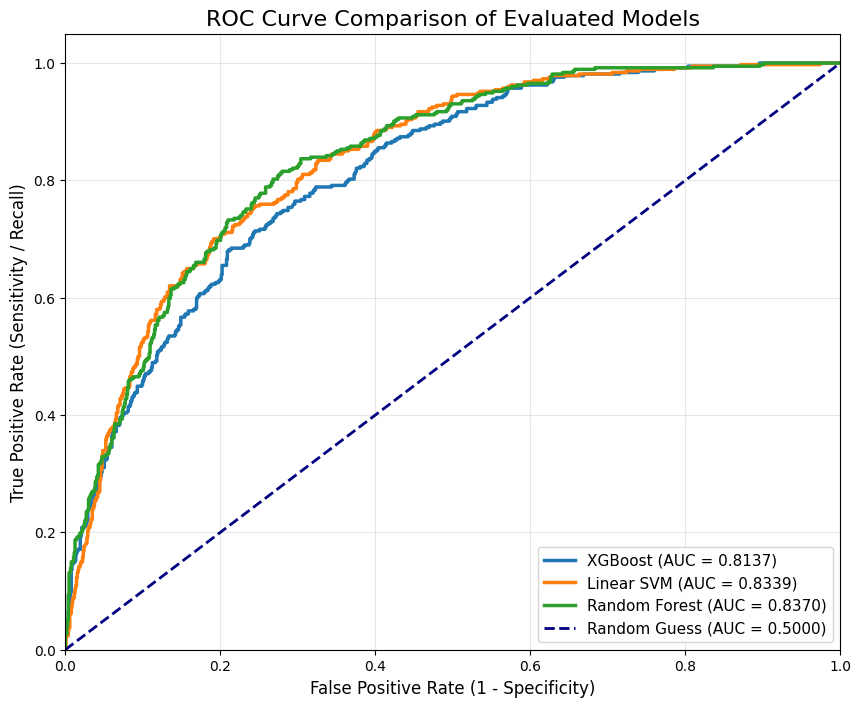

In [105]:
from sklearn.metrics import roc_curve, auc # Import roc_curve and auc for ROC plotting

# 1. Define model configurations mapped to their specific datasets
model_configs = {
    'XGBoost': {
        'file': 'Telco_Churn_RFE_Selected_XGBoost.csv',
        'model': XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1) # Removed 'use_label_encoder'
    },
    'Linear SVM': {
        'file': 'Telco_Churn_RFE_Selected_LinearSVM.csv',
        'model': LinearSVC(random_state=42, dual=False, max_iter=5000)
    },
    'Random Forest': {
        'file': 'Telco_Churn_RFE_Selected_RandomForest.csv',
        'model': RandomForestClassifier(random_state=42, n_jobs=-1, max_depth=7)
    }
}

# 2. Set up the Matplotlib Figure
fig, ax = plt.subplots(figsize=(10, 8))

# 3. Train, Evaluate, and Plot each model
for name, config in model_configs.items():
    # Load specific dataset
    df = pd.read_csv(config['file'])
    X = df.drop(columns=['Churn'])
    y = df['Churn']

    # Split Data (80/20 Stratified)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # Train the model
    model = config['model']
    model.fit(X_train, y_train)

    # Predict probabilities (SVM uses decision_function, Trees use predict_proba)
    if name == 'Linear SVM':
        y_score = model.decision_function(X_test)
    else:
        y_score = model.predict_proba(X_test)[:, 1]

    # Calculate False Positive Rate, True Positive Rate, and Area Under Curve
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)

    # Plot the curve for this specific model
    ax.plot(fpr, tpr, lw=2.5, label=f'{name} (AUC = {roc_auc:.4f})')

# 4. Add visual formatting
ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess (AUC = 0.5000)')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
ax.set_ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=12)
ax.set_title('ROC Curve Comparison of Evaluated Models', fontsize=16)
ax.legend(loc="lower right", fontsize=11)
ax.grid(True, alpha=0.3)

# 5. Show and Save
plt.savefig('roc_auc_comparison.png', bbox_inches='tight')
plt.show()

In [107]:
from sklearn.model_selection import RandomizedSearchCV

# 1. Define models, parameter grids, and target files
model_configs = {
    'XGBoost': {
        'file': 'Telco_Churn_RFE_Selected_XGBoost.csv',
        'model': XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1),
        'params': {
            'n_estimators': [100, 200, 300, 500],       # Number of trees
            'max_depth': [3, 5, 7, 10],                 # Max depth of trees
            'learning_rate': [0.01, 0.05, 0.1, 0.2],    # Step size shrinkage
            'subsample': [0.6, 0.8, 1.0],               # Fraction of samples used per tree
            'colsample_bytree': [0.6, 0.8, 1.0]         # Fraction of features used per tree
        }
    },
    'Linear SVM': {
        'file': 'Telco_Churn_RFE_Selected_LinearSVM.csv',
        'model': LinearSVC(random_state=42, dual=False, max_iter=5000),
        'params': {
            'C': [0.001, 0.01, 0.1, 1, 10, 100],        # Regularization parameter
            'class_weight': [None, 'balanced']          # Handles imbalanced data
        }
    },
    'Random Forest': {
        'file': 'Telco_Churn_RFE_Selected_RandomForest.csv',
        'model': RandomForestClassifier(random_state=42, n_jobs=-1),
        'params': {
            'n_estimators': [100, 200, 300, 500],       # Number of trees
            'max_depth': [5, 10, 15, 20, None],         # Max depth of trees
            'min_samples_split': [2, 5, 10],            # Minimum samples required to split
            'class_weight': [None, 'balanced', 'balanced_subsample']
        }
    }
}

final_results = {}

# 2. Iterate, Tune, and Evaluate
for name, config in model_configs.items():
    print(f"========== Optimizing {name} ==========")

    # Load specific feature-selected dataset
    df = pd.read_csv(config['file'])
    X = df.drop(columns=['Churn'])
    y = df['Churn']

    # Split Data (80/20)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # Setup RandomizedSearchCV
    # n_iter=20 means it will randomly test 20 different parameter combinations.
    # cv=5 means 5-fold cross-validation.
    search = RandomizedSearchCV(
        estimator=config['model'],
        param_distributions=config['params'],
        n_iter=20,
        cv=5,
        scoring='roc_auc',  # Optimize specifically for the ROC-AUC score
        random_state=42,
        n_jobs=-1,          # Use all computer cores to speed up processing
        verbose=1           # Shows progress bar in terminal
    )

    # Run the tuning process (this fits the model on X_train)
    search.fit(X_train, y_train)

    # Extract the absolute best model it found
    best_model = search.best_estimator_

    # Evaluate the BEST model on the unseen Test Set
    if name == 'Linear SVM':
        y_prob = best_model.decision_function(X_test)
    else:
        y_prob = best_model.predict_proba(X_test)[:, 1]

    y_pred = best_model.predict(X_test)
    test_roc_auc = roc_auc_score(y_test, y_prob)

    # Print out results
    print(f"\nOptimization Complete for {name}:")
    print(f"-> Best Parameters Found: {search.best_params_}")
    print(f"-> Cross-Validation ROC-AUC: {search.best_score_:.4f}")
    print(f"-> Final Test Set ROC-AUC:   {test_roc_auc:.4f}\n")
    print(classification_report(y_test, y_pred))
    print("\n" + "="*50 + "\n")

========== Optimizing XGBoost ==========
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Optimization Complete for XGBoost:
-> Best Parameters Found: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.6}
-> Cross-Validation ROC-AUC: 0.8482
-> Final Test Set ROC-AUC:   0.8384

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



========== Optimizing Linear SVM ==========
Fitting 5 folds for each of 12 candidates, totalling 60 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 12 is smaller than n_iter=20. Running 12 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(



Optimization Complete for Linear SVM:
-> Best Parameters Found: {'class_weight': 'balanced', 'C': 0.01}
-> Cross-Validation ROC-AUC: 0.8446
-> Final Test Set ROC-AUC:   0.8339

              precision    recall  f1-score   support

           0       0.90      0.71      0.79      1033
           1       0.49      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407



========== Optimizing Random Forest ==========
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Optimization Complete for Random Forest:
-> Best Parameters Found: {'n_estimators': 300, 'min_samples_split': 10, 'max_depth': 10, 'class_weight': 'balanced_subsample'}
-> Cross-Validation ROC-AUC: 0.8454
-> Final Test Set ROC-AUC:   0.8367

              precision    recall  f1-score   support

           0       0.90      0.76      0.83      1033
           1       0.54      0.7

## Expert Business Recommendations Based on the Telco Churn Model

Based on the notebook, churn is mainly driven by **fiber optic customers, electronic check users, high monthly charges, short tenure, month-to-month contracts, lack of online security, and lack of tech support**. The business should treat churn as a **targeted retention problem**, not a general customer satisfaction issue.

### 1. Prioritize month-to-month customers for retention

The strongest business signal is that customers on **two-year contracts churn far less**, while short-tenure and month-to-month customers are much more likely to leave.

**Recommendation:**
Create a contract-conversion campaign for month-to-month customers, especially those in their first 6–12 months.

**Actions:**

* Offer discounted upgrades to 1-year or 2-year contracts.
* Provide loyalty credits after 3, 6, and 12 months.
* Bundle contract renewal with free add-ons such as tech support or online security.

**Business rationale:**
Longer contracts and longer tenure are strongly associated with lower churn, so the company should focus on moving customers from flexible, high-risk relationships into stickier long-term plans.

---

### 2. Investigate fiber optic customer dissatisfaction

The model shows **fiber optic service has one of the strongest positive relationships with churn**. This is a major business warning because fiber customers usually pay more and should be high-value customers.

**Recommendation:**
Treat fiber optic churn as a priority operational issue.

**Actions:**

* Audit service quality for fiber customers: outages, installation issues, speed complaints, support tickets.
* Compare fiber pricing against competitors.
* Create a “fiber save desk” for customers showing churn risk.
* Offer speed guarantees, service credits, or plan optimization.

**Business rationale:**
Fiber optic customers may be churning because of either **price sensitivity, service reliability problems, or unmet expectations**. Losing them is especially damaging because they likely generate higher monthly revenue.

---

### 3. Reduce churn among electronic check users

The notebook shows **electronic check payment method has a strong positive correlation with churn**, while automatic credit card payment is associated with lower churn.

**Recommendation:**
Move high-risk customers from electronic check to automatic payment methods.

**Actions:**

* Offer a small monthly discount for auto-pay enrollment.
* Promote bank transfer or credit card automatic payment.
* Simplify payment setup inside the customer portal.
* Target electronic check customers with churn-prevention messaging.

**Business rationale:**
Payment method may act as a behavioral signal. Customers using electronic checks may be less committed, more price-sensitive, or more likely to cancel manually. Auto-pay creates friction against churn and improves revenue predictability.

---

### 4. Use online security and tech support as retention products

Customers with **online security and tech support show lower churn**. These services appear to increase customer stickiness.

**Recommendation:**
Reposition online security and tech support as retention tools, not just add-on revenue products.

**Actions:**

* Bundle online security and tech support into high-risk customer offers.
* Provide free trials to new customers during the first 90 days.
* Include these services in retention packages for fiber and month-to-month customers.
* Train agents to recommend these add-ons when churn risk is high.

**Business rationale:**
Support-related services likely increase perceived value and reduce frustration. They can make customers feel more protected and supported, reducing the likelihood of switching providers.

---

### 5. Build an early-tenure intervention program

Tenure has the strongest negative relationship with churn in the notebook. In simple terms, **new customers are the most vulnerable**.

**Recommendation:**
Launch a structured onboarding and early-life retention program.

**Actions:**

* Contact new customers within the first 30 days.
* Monitor installation satisfaction, billing issues, and service complaints.
* Send personalized usage tips and plan-fit recommendations.
* Trigger retention offers before the first renewal or billing dissatisfaction point.

**Business rationale:**
Once customers survive the early relationship period, they are less likely to churn. The first few months should be treated as a critical customer-success window.

---

### 6. Manage high monthly charge sensitivity

The model shows **higher monthly charges are positively associated with churn**. This suggests price-value mismatch may be a major churn driver.

**Recommendation:**
Create proactive bill-shock and plan-optimization programs.

**Actions:**

* Identify customers with high monthly charges and no long-term contract.
* Recommend cheaper or better-fit plans before they cancel.
* Offer temporary discounts only to high-risk, high-value customers.
* Avoid blanket discounts; use the churn model to target offers.

**Business rationale:**
Not all expensive customers are unhappy, but high charges combined with short tenure, fiber service, and month-to-month contracts represent a high-risk segment.

---

### 7. Segment senior citizens separately

Senior-citizen status has a positive relationship with churn in the notebook.

**Recommendation:**
Create a specialized retention and support experience for senior customers.

**Actions:**

* Offer simpler billing explanations.
* Provide phone-based support rather than purely digital support.
* Create senior-friendly plan bundles.
* Reduce hidden fees and confusing add-ons.

**Business rationale:**
Senior customers may churn due to billing confusion, support friction, or lower tolerance for complex digital service management.

---

## Recommended Churn Strategy

The company should create a **risk-based retention engine** using the model output.

The highest-priority churn segment is:

> **Month-to-month fiber optic customers with short tenure, high monthly charges, electronic check payment, no tech support, and no online security.**

These customers should receive the most aggressive retention treatment because they combine multiple churn risk factors from the notebook.

---

## Model Deployment Recommendation

The model results show decent predictive performance:

* Linear SVM achieved around **80% accuracy** and **0.834 ROC-AUC** before tuning.
* Tuned XGBoost reached about **0.838 ROC-AUC**.
* Tuned Random Forest reached about **0.837 ROC-AUC**.
* Tuned Linear SVM improved churn recall to about **79%**, but with lower precision.

From a business perspective, the company should not optimize only for accuracy. Since churners are the minority class, the better goal is **high churn recall**, meaning the model should catch as many likely churners as possible.

**Recommended model for business use:**
Use the tuned **Random Forest or Linear SVM with class balancing**, depending on campaign budget.

* Use **Linear SVM** when the business wants to catch more potential churners.
* Use **Random Forest** when the business wants a more balanced approach with better precision.
* Use **XGBoost** if the business prioritizes ROC-AUC and plans to tune decision thresholds carefully.

---

## Important Expert Caveat

Before production use, the notebook needs cleanup. The code remaps the `Churn` column twice, which creates `NaN` values and forces the notebook to reload the dataset later. This should be fixed before deployment.

Also, the current analysis is mostly correlation-based. The business should run controlled experiments, such as A/B testing discounts, support bundles, and contract-conversion offers, before assuming every driver causes churn.

## Final Business Recommendation

The company should focus retention investment on **early-tenure, month-to-month, fiber optic customers paying high monthly charges through electronic check**. The best commercial levers are **contract conversion, auto-pay migration, service quality improvement, targeted discounts, and bundled support/security services**. This approach is more profitable than broad discounting because it targets customers with the highest predicted churn risk and the strongest business value.
